In [132]:
import random
from matplotlib import pyplot as plt


def show_random_samples_fixed(images, labels, height=57, width=72, num=10):
    plt.figure(figsize=(18, 4))
    indices = random.sample(range(len(images)), min(num, len(images)))

    for i, idx in enumerate(indices):
        img = images[idx]

        # Check if the pixel count matches your expected reshape
        if img.size != height * width:
            print(f"Error: Image size is {img.size}, but you are trying to reshape to {height}x{width}")
            # Dynamic fix attempt (assuming height remains 72)
            width = int(img.size / height)

        plt.subplot(1, num, i + 1)
        plt.imshow(img.reshape(height, width), cmap='gray')
        plt.title(f"{labels[idx]}")
        plt.axis('off')
    plt.show()

def crop_grey_strips(img, strip_width=7, target_color=127, tolerance=10):
    """
    Detects if a 127-intensity (7F7F7F) grey strip exists on the left or right
    and crops it. Returns a resized image to maintain consistency.
    """
    h, w = img.shape

    # Calculate the average intensity of the far left and far right columns
    left_side_avg = np.mean(img[:, :strip_width])
    right_side_avg = np.mean(img[:, -strip_width:])

    # Determine crop boundaries
    start_col = 0
    end_col = w

    # Check if left side matches the grey strip color
    if abs(left_side_avg - target_color) <= tolerance:
        start_col = strip_width

    # Check if right side matches (using 'elif' assumes only one side has it)
    elif abs(right_side_avg - target_color) <= tolerance:
        end_col = w - strip_width

    # Perform the crop
    cropped_img = img[:, start_col:end_col]

    # CRITICAL: Resize back to the original width (64) or a new fixed width (55)
    # If we don't resize, the flattened vectors will have different lengths.
    # Let's resize to 72x55 since that's the "real" face data area.
    final_img = cv2.resize(cropped_img, (72, 57), interpolation=cv2.INTER_AREA)

    return final_img

Flatten all files into 1d vectors and put them in variables.

In [133]:
import numpy as np
import cv2
from pathlib import Path

def load_filtered_data(directory, threshold=20):
    images = []
    labels = []
    removed_count = 0

    path_list = list(Path(directory).glob('*.pgm'))

    for img_path in path_list:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = crop_grey_strips(img)

        if img is not None:
            # Calculate the average brightness of the image
            if np.mean(img) > threshold:
                images.append(img.flatten())
                labels.append(img_path.name.split('_')[0])
            else:
                removed_count += 1

    print(f"Directory: {directory}")
    print(f"Kept: {len(images)} | Removed (too dark): {removed_count}")
    return np.array(images), np.array(labels)

# Example usage:
X_train, y_train = load_filtered_data('Train Set (Split)/train', threshold=0)
X_test, y_test = load_filtered_data('Train Set (Split)/test', threshold=0)

print(f"X_train shape: {X_train.shape}")  # Should be (~14364, 4608)
print(f"X_test shape: {X_test.shape}")    # Should be (~1596, 4608)

Directory: Train Set (Split)/train
Kept: 11164 | Removed (too dark): 3215
Directory: Train Set (Split)/test
Kept: 1264 | Removed (too dark): 361
X_train shape: (11164, 4104)
X_test shape: (1264, 4104)


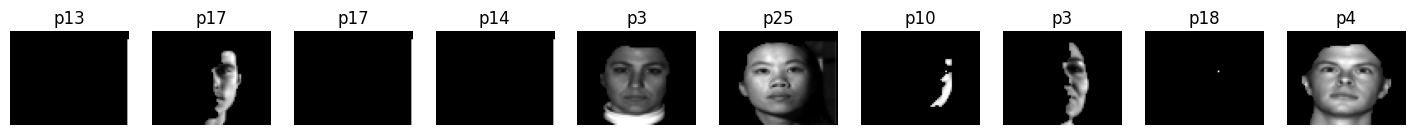

In [134]:
show_random_samples_fixed(X_train, y_train)

Run PCA to determine maximum variation directions.

In [135]:
from skimage.exposure import exposure
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# --- 0. ENCODE LABELS FOR PLOTTING ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# --- 1. RESHAPE RAW DATA FOR HOG ---
X_train_images = X_train.reshape(-1, 57, 72)
X_test_images = X_test.reshape(-1, 57, 72)

# --- 2. EXTRACT HOG FEATURES ---
def get_hog_features(images):
    features_list = []
    for img in images:
        fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        features_list.append(fd)
    return np.array(features_list)

print("Extracting HOG features... (this might take a few seconds)")
X_train_hog = get_hog_features(X_train_images)
X_test_hog = get_hog_features(X_test_images)

# --- 3. SCALE BOTH DATASETS INDEPENDENTLY ---
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

# --- 4. APPLY PCA TO COMPRESS BOTH ---
pca_hog = PCA(n_components=150, whiten=True)
X_train_hog_pca = pca_hog.fit_transform(X_train_hog_scaled)
X_test_hog_pca = pca_hog.transform(X_test_hog_scaled)

pca_raw = PCA(n_components=150, whiten=True)
X_train_raw_pca = pca_raw.fit_transform(X_train_raw_scaled)
X_test_raw_pca = pca_raw.transform(X_test_raw_scaled)

# --- 5. CONCATENATE (GLUE) THEM TOGETHER ---
X_train_final = np.hstack((X_train_hog_pca, X_train_raw_pca))
X_test_final = np.hstack((X_test_hog_pca, X_test_raw_pca))

print(f"Final training data shape: {X_train_final.shape}")

Extracting HOG features... (this might take a few seconds)
Final training data shape: (11164, 300)


In [136]:
from sklearn.svm import SVC

# 'Linear' kernel is usually sufficient after LDA
# 'C=1' is a good starting point for regularization
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train_final, y_train)
y_pred = svm_clf.predict(X_test_final)

print(f"SVM Accuracy: {svm_clf.score(X_test_final, y_test) * 100:.2f}%")

SVM Accuracy: 46.99%


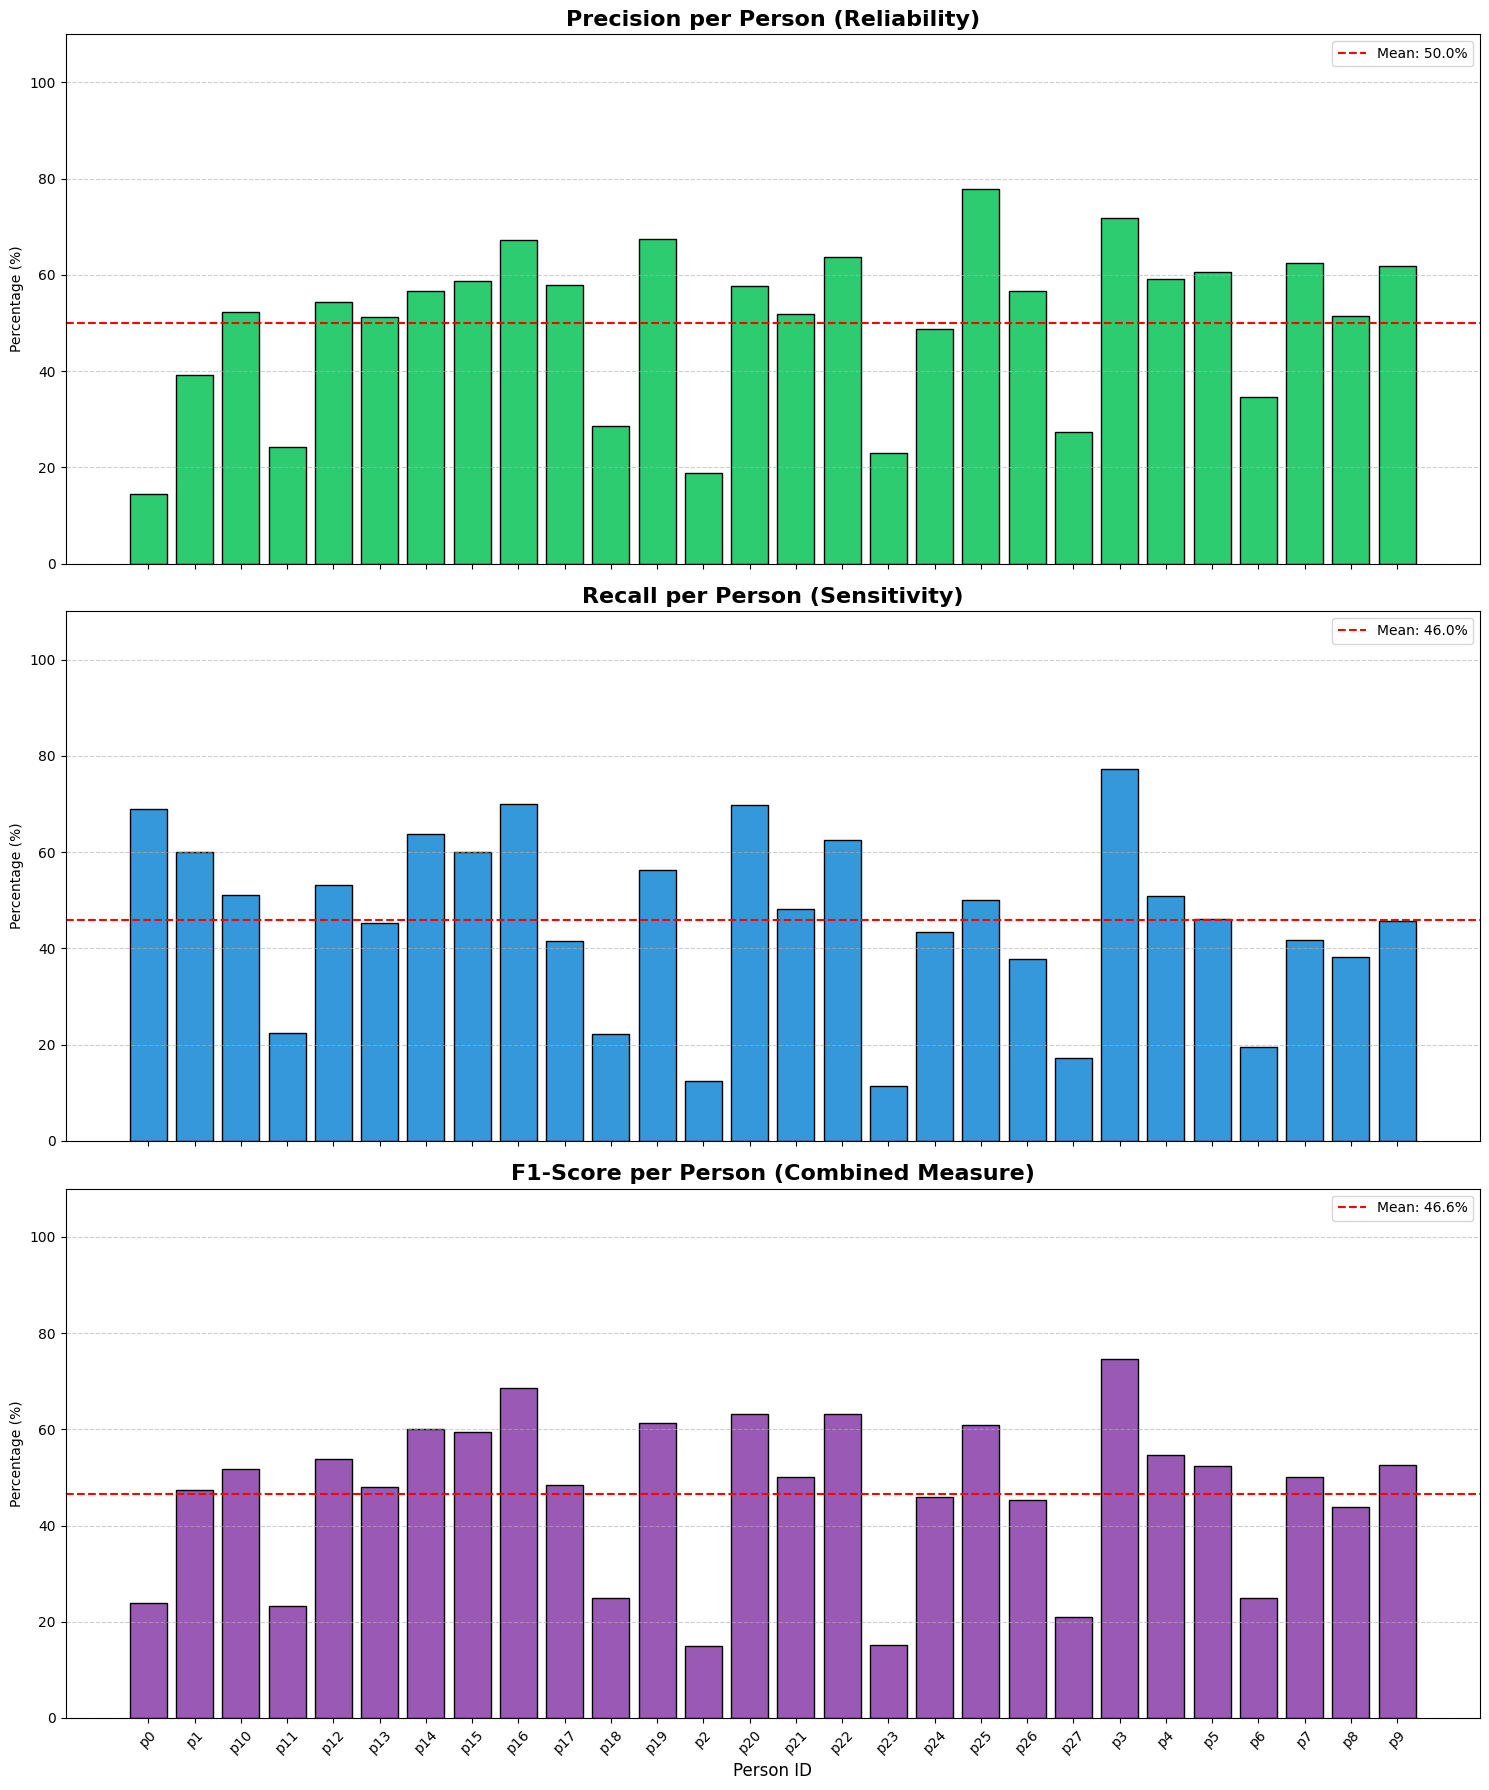

In [137]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate the classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# 2. Convert to DataFrame and clean up
# We remove 'accuracy', 'macro avg', and 'weighted avg' to keep only the 28 people
metrics_df = pd.DataFrame(report).transpose()
metrics_df = metrics_df.drop(['accuracy', 'macro avg', 'weighted avg'])

# Add 'accuracy' column per person (in multi-class, Recall is often equivalent
# to per-class accuracy, but we'll plot the three standard metrics)
metrics_df = metrics_df[['precision', 'recall', 'f1-score']] * 100
metrics_df = metrics_df.sort_index() # Keep people in order p1, p2...

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

metrics = ['precision', 'recall', 'f1-score']
colors = ['#2ecc71', '#3498db', '#9b59b6']
titles = ['Precision per Person (Reliability)',
          'Recall per Person (Sensitivity)',
          'F1-Score per Person (Combined Measure)']

for i, metric in enumerate(metrics):
    axes[i].bar(metrics_df.index, metrics_df[metric], color=colors[i], edgecolor='black')
    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 110)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    # Add a horizontal line for the average
    avg_val = metrics_df[metric].mean()
    axes[i].axhline(avg_val, color='red', linestyle='--', label=f'Mean: {avg_val:.1f}%')
    axes[i].legend()

plt.xticks(rotation=45)
plt.xlabel('Person ID', fontsize=12)
plt.tight_layout()
plt.show()